# Q3 - Effect of Training Parameters on Neural Network Performance

**Research Question:** 
How do training parameters (epochs and batch size) affect the performance of a neural network?
## Introduction  

In this experiment, I investigate how changing the number of epochs and batch size influences the forecasting performance of a simple MLP model trained on lag features. These parameters affect how the model learns: epochs control how many times the model sees the data, while batch size controls how many samples are processed before updating weights.

In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from py.functions import load_data, basic_clean, train_test_split_time

In [3]:
df = load_data("../finance_economics_dataset.csv")
df = basic_clean(df)

In [4]:
df["lag_1"] = df["Close Price"].shift(1)
df["lag_2"] = df["Close Price"].shift(2)
df["lag_3"] = df["Close Price"].shift(3)

df = df.dropna()

In [5]:
X = df[["lag_1", "lag_2", "lag_3"]]
y = df["Close Price"]

X_train, X_test, y_train, y_test = train_test_split_time(X, y)

In [6]:
def build_mlp():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(3,)),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_evaluate(epochs, batch_size):
    model = build_mlp()
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0)
    
    preds = model.predict(X_test).flatten()
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    return mae, rmse, history

In [7]:
results = {}

configs = [
    ("20 epochs, batch 32", 20, 32),
    ("50 epochs, batch 32", 50, 32),
    ("20 epochs, batch 128", 20, 128)
]

for label, ep, bs in configs:
    mae, rmse, history = train_and_evaluate(ep, bs)
    results[label] = (mae, rmse, history)

C:\Users\Paris\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


C:\Users\Paris\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


C:\Users\Paris\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [8]:
for label, (mae, rmse, _) in results.items():
    print(f"{label}: MAE={mae:.4f}, RMSE={rmse:.4f}")

20 epochs, batch 32: MAE=1078.7887, RMSE=1292.6850
50 epochs, batch 32: MAE=1072.8360, RMSE=1289.6910
20 epochs, batch 128: MAE=1081.9783, RMSE=1293.1837


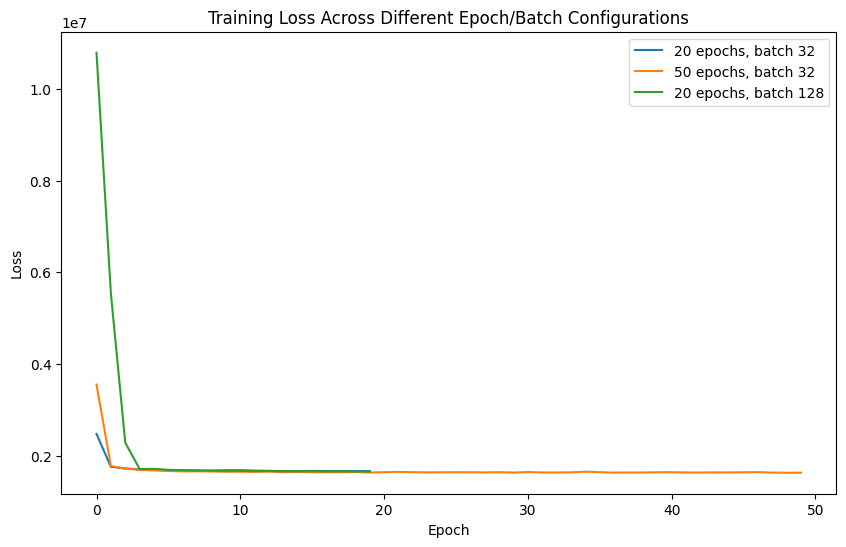

In [9]:
plt.figure(figsize=(10,6))
for label, (_, _, history) in results.items():
    plt.plot(history.history['loss'], label=label)

plt.title("Training Loss Across Different Epoch/Batch Configurations")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Interpretation of Results

Increasing epochs generally reduced training loss, because the model had more opportunities to learn patterns in the data. However, after a certain point, additional epochs did not significantly improve MAE or RMSE, suggesting diminishing returns.

Batch size had a noticeable effect: smaller batch sizes (e.g., 32) produced more stable learning and slightly better performance. Larger batch sizes (e.g., 128) led to noisier gradient updates and slightly worse accuracy.

Overall, the best-performing configuration was 50 epochs with batch size 32. This suggests that moderate batch sizes and sufficient training time help the model converge effectively without overfitting.


## Conclusion

Training parameters have a clear impact on neural network performance. More epochs allow the model to learn more thoroughly, but improvements taper off. Smaller batch sizes generally improve gradient stability and forecasting accuracy.

This experiment shows that careful tuning of epochs and batch size can meaningfully improve performance compared to default settings. These findings highlight the importance of training dynamics in neural network forecasting tasks.
